In [27]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import os

downloads = os.path.join(os.path.expanduser("~"), "Downloads")

filename = os.path.join(downloads, "Fluc_erg_TC_Kac_WS.npz")

data = np.load(filename)

# extract arrays
N_arr = data["N"]
E_ergo = data["Eerg"]
E_var = data["variance"]
E_ratio = data["ratio"]
E_B = data["Eb"]

# derived quantities
F_ratio = np.sqrt(E_var) / E_ergo
FE_ratio = np.sqrt(E_var) / E_B

In [28]:
N = data["N"]
tau = data["tau"]
Eb = data["Eb"]
Eerg = data["Eerg"]
ratio = data["ratio"]
variance = data["variance"]

for i in range(len(N)):
    print(
        f"N={N[i]}, "
        f"τ={tau[i]:.4f}, "
        f"Eb={Eb[i]:.6f}, "
        f"Ergotropy={Eerg[i]:.6f}, "
        f"Ratio={ratio[i]:.6f}, "
        f"Variance={variance[i]:.10e},"
        f"Fluctuation w.r.t erg={F_ratio[i]:.10e},"
        f"Fluctuation w.r.t EB={FE_ratio[i]:.10e}"
    )

N=2, τ=0.9584, Eb=1.051391, Ergotropy=1.014536, Ratio=0.964946, Variance=5.7193620668e-01,Fluctuation w.r.t erg=7.4542910187e-01,Fluctuation w.r.t EB=7.1929899788e-01
N=6, τ=1.0403, Eb=3.552231, Ergotropy=3.497159, Ratio=0.984496, Variance=1.8081903106e+00,Fluctuation w.r.t erg=3.8450920357e-01,Fluctuation w.r.t EB=3.7854792188e-01
N=10, τ=1.0634, Eb=6.105073, Ergotropy=6.043768, Ratio=0.989958, Variance=3.0524961209e+00,Fluctuation w.r.t erg=2.8908113896e-01,Fluctuation w.r.t EB=2.8617828271e-01
N=14, τ=1.0746, Eb=8.671334, Ergotropy=8.606820, Ratio=0.992560, Variance=4.2987518715e+00,Fluctuation w.r.t erg=2.4089538486e-01,Fluctuation w.r.t EB=2.3910314640e-01
N=18, τ=1.0811, Eb=11.241644, Ergotropy=11.175207, Ratio=0.994090, Variance=5.5456255296e+00,Fluctuation w.r.t erg=2.1072676190e-01,Fluctuation w.r.t EB=2.0948139263e-01
N=22, τ=1.0854, Eb=13.814590, Ergotropy=13.746857, Ratio=0.995097, Variance=6.7928711065e+00,Fluctuation w.r.t erg=1.8959341931e-01,Fluctuation w.r.t EB=1.88663

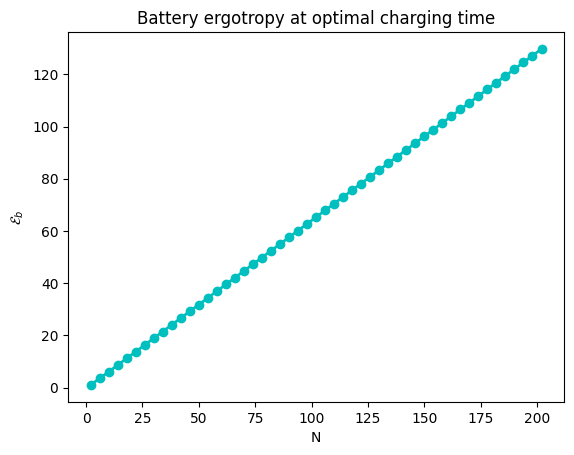

In [29]:
###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
#plt.savefig("OP1")
plt.show()

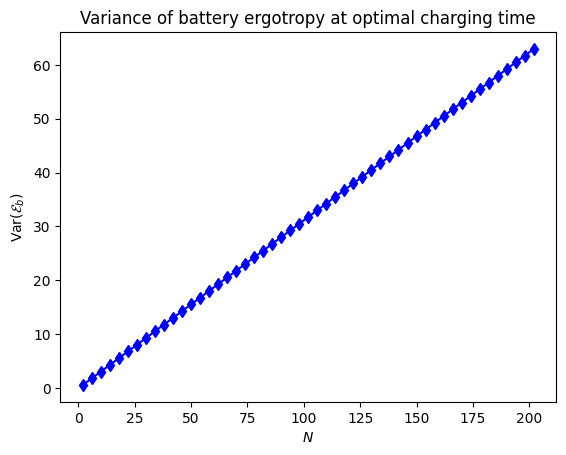

In [30]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
#plt.savefig("OP2")
plt.show()

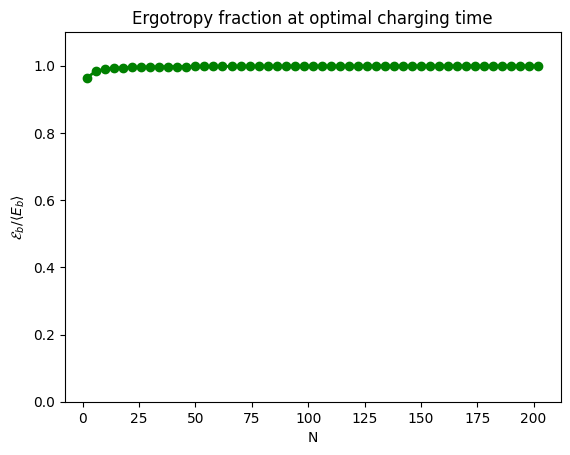

In [31]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
# plt.savefig("OP3")
plt.show()

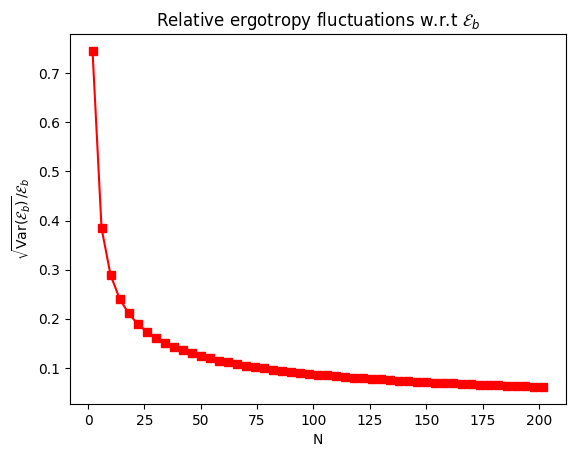

In [32]:
######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
# plt.savefig("OP4")
plt.show()

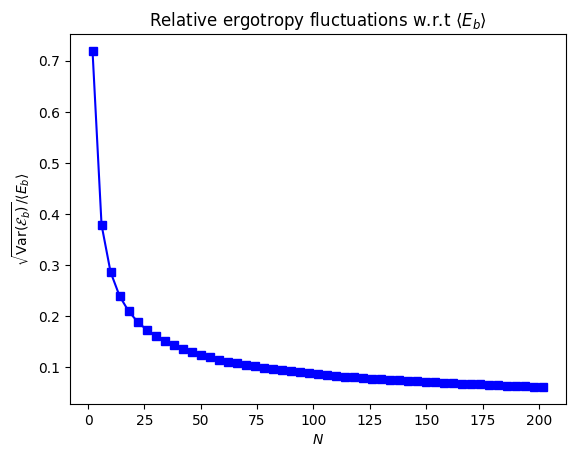

In [33]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
# plt.savefig("OP5")
plt.show()

### Scaling of $1 - \mathcal{E}_b / \langle E_b \rangle$

Best fit parameter: A = 0.113522


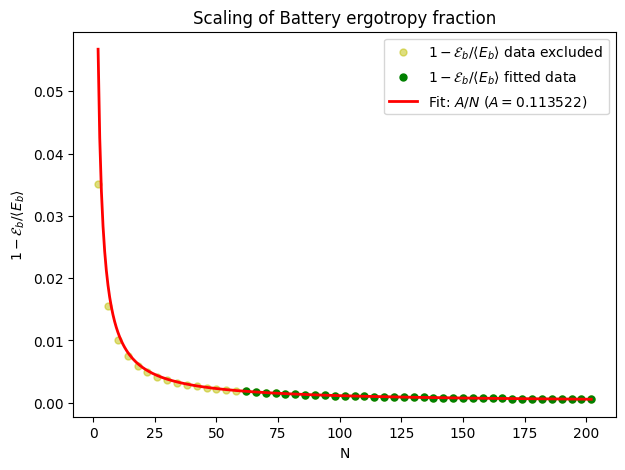

In [34]:
###############################
# Scaling using a linear plot
##############################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function
def asymptotic_fit(N, A):
    return A / N

y_full = 1 - np.array(E_ratio)

# Restrict fitting data
N_data = N_arr[15:51]
y_data = 1 - np.array(E_ratio[15:51])

# Fit only restricted region
popt, pcov = curve_fit(asymptotic_fit, N_data, y_data)

A_opt = popt[0]

print(f"Best fit parameter: A = {A_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_fit = asymptotic_fit(N_smooth, A_opt)

plt.figure(figsize=(7, 5))

# Plot the FULL dataset with faded colours 
plt.plot(N_arr, y_full, 'o', color='y', markersize=5, alpha=0.5, label=r"$1 - \mathcal{E}_b / \langle E_b \rangle$ data excluded")

# Plot restricted actual data
plt.plot(N_data, y_data, 'o', color='g', markersize=5, label=r"$1 - \mathcal{E}_b / \langle E_b \rangle$ fitted data")

# Plot fit over FULL range
plt.plot(N_smooth, y_fit, '-', color='r', linewidth=2, label=rf'Fit: $A/N$ ($A={A_opt:.6f}$)')

plt.xlabel("N")
plt.ylabel(r"$1 - \mathcal{E}_b / \langle E_b \rangle$")
plt.title("Scaling of Battery ergotropy fraction")
plt.legend()
plt.show()

Best fit parameter: A = 0.106602, alpha = 0.986248


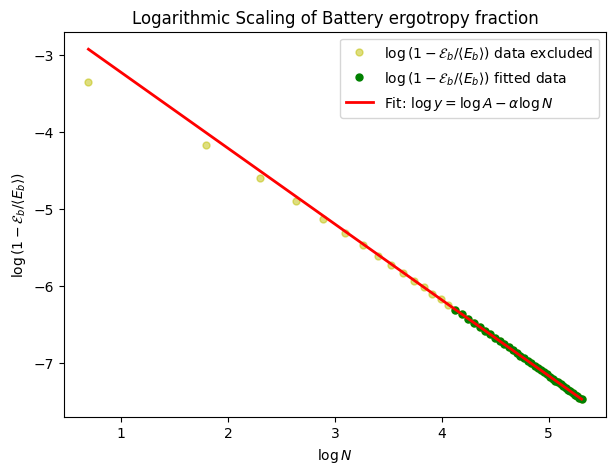

In [35]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit1(log_N, logA, alpha1):
    return logA - alpha1 *log_N

y_full = 1 - np.array(E_ratio)

# Restrict fitting data
N_data1 = N_arr[15:51]
y_data1 = y_full[15:51]

# Keep only positive values for the logarithm
mask = (N_data1 > 0) & (y_data1 > 0)

N_fit1 = N_data1[mask]
y_fit_data1 = y_data1[mask]

# Logarithmic variables
log_N = np.log(N_fit1)
log_y = np.log(y_fit_data1)

# Fit in log-space
popt, pcov = curve_fit(log_fit1, log_N, log_y)

logA_opt, alpha_opt = popt

A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}, alpha = {alpha_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_smooth = A_opt / (N_smooth**alpha_opt)

plt.figure(figsize=(7, 5))

# Plot FULL dataset with faded colours
plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ fitted data")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=rf'Fit: $\log y = \log A - \alpha\log N$')

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$")
plt.title("Logarithmic Scaling of Battery ergotropy fraction")
plt.legend()
plt.show()

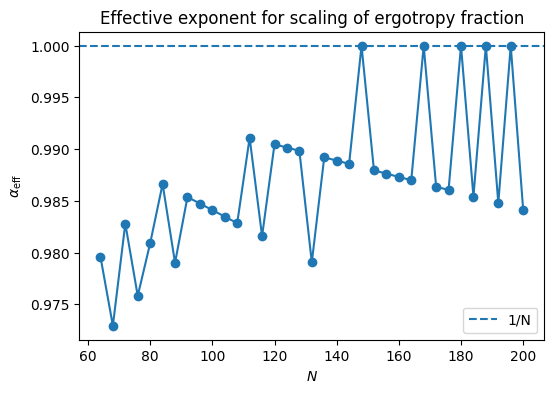

In [36]:
alpha_eff = -np.diff(np.log(y_fit_data1)) / np.diff(np.log(N_fit1))

N_mid = 0.5 * (N_fit1[:-1] + N_fit1[1:])

plt.figure(figsize=(6,4))

plt.plot(N_mid, alpha_eff, 'o-')

plt.axhline(1, ls='--', label='1/N')

plt.xlabel(r"$N$")
plt.ylabel(r"$\alpha_{\rm eff}$")
plt.title("Effective exponent for scaling of ergotropy fraction")
plt.legend()
plt.show()

### Scaling of $\sqrt var(\mathcal{E}_b) / \mathcal{E}_b$

Best fit parameter: A = 9.580950


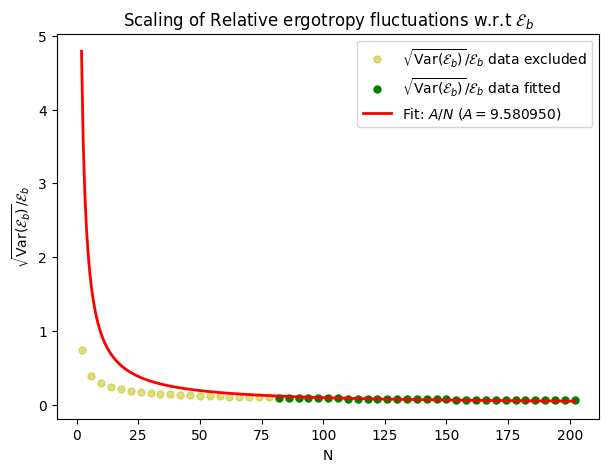

In [37]:
###############################
# Scaling using a linear plot
##############################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function
def asymptotic_fit(N, A):
    return A / N

y_full = np.array(F_ratio)

# Restrict fitting data
N_data = N_arr[20:51]
y_data = np.array(F_ratio[20:51])

# Fit only restricted region
popt, pcov = curve_fit(asymptotic_fit, N_data, y_data)

A_opt = popt[0]

print(f"Best fit parameter: A = {A_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_fit = asymptotic_fit(N_smooth, A_opt)

plt.figure(figsize=(7, 5))

# Plot the FULL dataset with faded colours 
plt.plot(N_arr, y_full, 'o', color='y', markersize=5, alpha=0.5, label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$ data excluded")

# Plot restricted actual data
plt.plot(N_data, y_data, 'o', color='g', markersize=5, label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$ data fitted")

# Plot fit over FULL range
plt.plot(N_smooth, y_fit, '-', color='r', linewidth=2, label=rf'Fit: $A/N$ ($A={A_opt:.6f}$)')

plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Scaling of Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.legend()
plt.show()

Best fit parameter: A = 0.898034, alpha = 0.506324


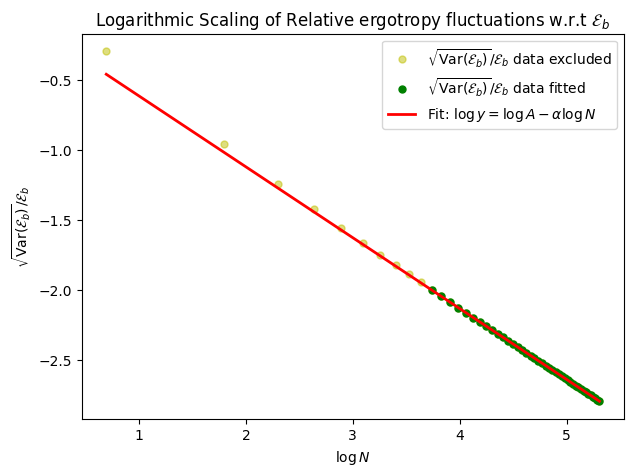

In [38]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit2(log_N, logA, alpha2):
    return logA - alpha2 *log_N

y_full = np.array(F_ratio)

# Restrict fitting data
N_data2 = N_arr[10:51]
y_data2 = y_full[10:51]

# Keep only positive values for the logarithm
mask = (N_data2 > 0) & (y_data2 > 0)

N_fit2 = N_data2[mask]
y_fit_data2 = y_data2[mask]

# Logarithmic variables
log_N = np.log(N_fit2)
log_y = np.log(y_fit_data2)

# Fit in log-space
popt, pcov = curve_fit(log_fit2, log_N, log_y)

logA_opt, alpha_opt = popt

A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}, alpha = {alpha_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_smooth = A_opt / (N_smooth**alpha_opt)

plt.figure(figsize=(7, 5))

# Plot FULL dataset with faded colours
plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$ data fitted")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=rf'Fit: $\log y = \log A - \alpha \log N$')

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Logarithmic Scaling of Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.legend()
plt.show()

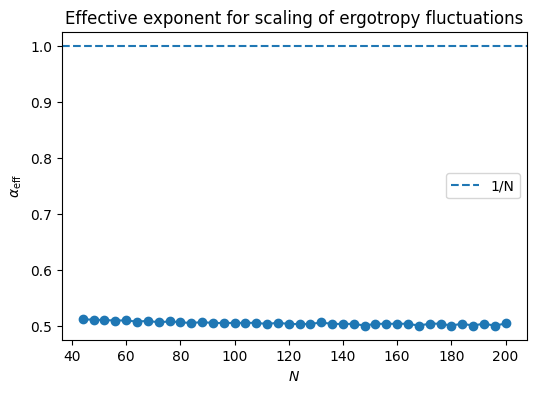

In [39]:
alpha_eff = -np.diff(np.log(y_fit_data2)) / np.diff(np.log(N_fit2))

N_mid = 0.5 * (N_fit2[:-1] + N_fit2[1:])

plt.figure(figsize=(6,4))

plt.plot(N_mid, alpha_eff, 'o-')

plt.axhline(1, ls='--', label='1/N')

plt.xlabel(r"$N$")
plt.ylabel(r"$\alpha_{\rm eff}$")
plt.title("Effective exponent for scaling of ergotropy fluctuations")
plt.legend()
plt.show()